# Modeling and Backtesting

**Project:** Energy Forecasting — Household Electricity Consumption (Enel × LUISS).

**Goal of this notebook:** train every model in our lineup against the same rolling-origin split plan, evaluate them with the same metric bundle, and produce the leaderboard required by the project brief.

**Reading order.** Each section adds models or analysis on top of the previous one, then surfaces what the numbers tell us before continuing. Models are added in order of complexity (baselines → classical → tree-based → deep learning → ensemble), so the reader always knows what bar the next model has to clear.

**Inputs read from disk:**
- [`data/processed/features.parquet`](../data/processed/features.parquet) — feature matrix produced by [`02_feature_engineering.ipynb`](02_feature_engineering.ipynb).
- [`data/processed/features.metadata.json`](../data/processed/features.metadata.json) — content-hash audit trail.

---

## 1 · Setup

In [1]:
# =============================================================
# 1.1  IMPORTS AND CONFIGURATION
# =============================================================
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from energy_forecasting.config import DEFAULT_CONFIG_PATH, ForecastConfig
from energy_forecasting.evaluation import compute_metrics
from energy_forecasting.models import NaiveLagBaseline
from energy_forecasting.splits import make_rolling_origin_splits, splits_to_dataframe
from energy_forecasting.utils import set_global_seed

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

cfg = ForecastConfig.from_yaml(DEFAULT_CONFIG_PATH)
set_global_seed(cfg.reproducibility.seed)

print(f"Config hash         : {cfg.content_hash()[:12]}")
print(f"Target              : {cfg.target.column}")
print(f"Primary metric      : {cfg.evaluation.primary_metric}")
print(f"Guardrail metrics   : {', '.join(cfg.evaluation.guardrail_metrics)}")
print(f"Splits              : {cfg.splits.n_folds} folds × {cfg.splits.valid_window_days}d valid")

Config hash         : 050755a0a6eb
Target              : Global_active_power
Primary metric      : MAE
Guardrail metrics   : RMSE, WAPE, MASE, sMAPE
Splits              : 6 folds × 30d valid


## 2 · Load the Feature Matrix

Read [`features.parquet`](../data/processed/features.parquet) and verify the metadata sidecar's `config_hash` matches the in-memory config — if they disagree, the artifact was built from a different config than we're modeling under, and we refuse to proceed.

In [2]:
# =============================================================
# 2.1  LOAD FEATURES + ASSERT CONFIG HASH MATCH
# =============================================================
features_path = Path("..") / "data" / "processed" / "features.parquet"
metadata_path = Path("..") / "data" / "processed" / "features.metadata.json"

metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
assert metadata["config_hash"] == cfg.content_hash(), (
    f"Config drift detected — features.parquet was built under hash "
    f"{metadata['config_hash'][:12]} but current config is {cfg.content_hash()[:12]}. "
    "Re-run 02_feature_engineering.ipynb before modeling."
)

df = pd.read_parquet(features_path)
y = df[cfg.target.column]
X = df.drop(columns=[cfg.target.column])

print(f"X shape             : {X.shape}")
print(f"y shape             : {y.shape}")
print(f"Date range          : {X.index.min()}  →  {X.index.max()}")
print(f"Built at (UTC)      : {metadata['built_at_utc']}")
print(f"Unsafe inputs       : {metadata['unsafe_inputs_dropped']} dropped")
print(f"Strict leakage safe : {metadata['strict_leakage_safe']}")

X shape             : (34000, 31)
y shape             : (34000,)
Date range          : 2006-12-23 17:00:00  →  2010-11-26 21:00:00
Built at (UTC)      : 2026-05-14T13:39:57+00:00
Unsafe inputs       : 6 dropped
Strict leakage safe : True


## 3 · Rolling-Origin Split Plan

Build the 6 folds from [`make_rolling_origin_splits`](../src/energy_forecasting/splits/rolling_origin.py) and confirm what we already discovered in [`reports/figures/split_plan_timeline.png`](../reports/figures/split_plan_timeline.png): three of the validation windows fall inside the August / September 2010 outage period, so their row counts will be short of the nominal 720 hours per fold.

In [3]:
# =============================================================
# 3.1  BUILD AND DISPLAY THE SPLIT PLAN
# =============================================================
folds = make_rolling_origin_splits(X.index, config=cfg)
plan = splits_to_dataframe(folds, index=X.index)

# Highlight folds where validation rows fall short of 30d × 24h = 720.
expected_valid_rows = cfg.splits.valid_window_days * 24
plan["valid_completeness"] = (plan["valid_rows"] / expected_valid_rows).round(3)
display(plan[["fold_id", "valid_start", "valid_end", "train_rows", "valid_rows", "valid_completeness"]])

print()
for _, row in plan.iterrows():
    fid = int(row["fold_id"])
    if row["valid_rows"] < expected_valid_rows:
        gap = expected_valid_rows - int(row["valid_rows"])
        print(f"  Fold {fid}: {gap:>3d} missing hours in validation — outage-affected window")

,fold_id,valid_start,valid_end,train_rows,valid_rows,valid_completeness
0,1,2010-05-30 22:00:00,2010-06-29 21:00:00,8607,720,1.000
1,2,2010-06-29 22:00:00,2010-07-29 21:00:00,8661,720,1.000
2,3,2010-07-29 22:00:00,2010-08-28 21:00:00,8661,601,0.835
3,4,2010-08-28 22:00:00,2010-09-27 21:00:00,8556,654,0.908
4,5,2010-09-27 22:00:00,2010-10-27 21:00:00,8490,699,0.971
5,6,2010-10-27 22:00:00,2010-11-26 21:00:00,8469,720,1.000



  Fold 3: 119 missing hours in validation — outage-affected window
  Fold 4:  66 missing hours in validation — outage-affected window
  Fold 5:  21 missing hours in validation — outage-affected window


## 4 · Naive Baselines — The Floor

Three naive baselines, each predicting $y_t = y_{t-\ell}$ for a fixed lag $\ell$. They share the same `BaseForecaster` interface as every model we'll add later, so the evaluation loop is uniform: instantiate, fit (no-op for naives), predict, score.

These set the floor every real model must clear. A real model that doesn't beat the *appropriate* naive (matching the forecast's seasonal scale) isn't doing anything — it's fitting noise.

- `naive_lag_1h`     — persistence: predict the next hour as the current hour.
- `naive_lag_24h`    — daily naive: predict same hour yesterday.
- `naive_lag_168h`   — weekly naive: predict same hour, same day-of-week, last week.

In [4]:
# =============================================================
# 4.1  FIT AND EVALUATE 3 NAIVE BASELINES ACROSS ALL 6 FOLDS
# =============================================================
target = cfg.target.column

baselines = [
    NaiveLagBaseline(f"{target}_lag_1h",   name="naive_lag_1h"),
    NaiveLagBaseline(f"{target}_lag_24h",  name="naive_lag_24h_daily"),
    NaiveLagBaseline(f"{target}_lag_168h", name="naive_lag_168h_weekly"),
]

all_rows: list[dict] = []
for fold in folds:
    X_train = X.loc[fold.train_start:fold.train_end]
    y_train = y.loc[fold.train_start:fold.train_end]
    X_valid = X.loc[fold.valid_start:fold.valid_end]
    y_valid = y.loc[fold.valid_start:fold.valid_end]

    for m in baselines:
        m.fit(X_train, y_train)
        y_pred = m.predict(X_valid)
        metrics = compute_metrics(
            y_valid.to_numpy(),
            y_pred,
            y_train=y_train.to_numpy(),
            seasonal_period=24,
        )
        all_rows.append({
            "fold": fold.fold_id,
            "model": m.name,
            "valid_rows": len(y_valid),
            **{k: round(v, 4) for k, v in metrics.items()},
        })

results = pd.DataFrame(all_rows)
print(f"Evaluated {results['model'].nunique()} models × {results['fold'].nunique()} folds = "
      f"{len(results)} (fold, model) pairs")
display(results)

Evaluated 3 models × 6 folds = 18 (fold, model) pairs


,fold,model,valid_rows,MAE,RMSE,WAPE,sMAPE,MASE
0,1,naive_lag_1h,720,0.4014,0.5864,0.4156,0.4142,0.6770
1,1,naive_lag_24h_daily,720,0.5163,0.7186,0.5345,0.5157,0.8708
2,1,naive_lag_168h_weekly,720,0.4797,0.6781,0.4966,0.4835,0.8090
3,2,naive_lag_1h,720,0.3086,0.4732,0.4090,0.3707,0.5226
4,2,naive_lag_24h_daily,720,0.4543,0.6424,0.6020,0.5225,0.7693
5,2,naive_lag_168h_weekly,720,0.5067,0.7022,0.6714,0.5912,0.8580
6,3,naive_lag_1h,601,0.2013,0.3477,0.3872,0.3129,0.3389
7,3,naive_lag_24h_daily,601,0.2103,0.4288,0.4045,0.2864,0.3541
8,3,naive_lag_168h_weekly,601,0.3565,0.5622,0.6855,0.5277,0.6001
9,4,naive_lag_1h,654,0.4204,0.5782,0.4402,0.4504,0.7169


## 5 · Aggregate Leaderboard

The canonical results table required by the project brief: mean ± std of every metric across folds, sorted by the primary metric (MAE).

Also persisted to [`reports/results/baseline_leaderboard.csv`](../reports/results/baseline_leaderboard.csv) so the technical-report build can pull from the same source as this notebook.

In [5]:
# =============================================================
# 5.1  AGGREGATE LEADERBOARD (mean +/- std)
# =============================================================
metric_cols = ["MAE", "RMSE", "WAPE", "sMAPE", "MASE"]
mean = results.groupby("model")[metric_cols].mean().round(4)
std = results.groupby("model")[metric_cols].std().round(4)

leaderboard = pd.DataFrame({
    f"{m}_mean": mean[m] for m in metric_cols
})
for m in metric_cols:
    leaderboard[f"{m}_std"] = std[m]
leaderboard = leaderboard.sort_values("MAE_mean")

# Persist for the report
out_dir = Path("..") / "reports" / "results"
out_dir.mkdir(parents=True, exist_ok=True)
leaderboard.to_csv(out_dir / "baseline_leaderboard.csv")
results.to_csv(out_dir / "baseline_fold_results.csv", index=False)

display(leaderboard)
print(f"Saved {out_dir / 'baseline_leaderboard.csv'}")
print(f"Saved {out_dir / 'baseline_fold_results.csv'}")

,MAE_mean,RMSE_mean,WAPE_mean,sMAPE_mean,MASE_mean,MAE_std,RMSE_std,WAPE_std,sMAPE_std,MASE_std
model,,,,,,,,,,
naive_lag_1h,0.3801,0.5628,0.4100,0.3916,0.6469,0.1071,0.1345,0.0199,0.0472,0.1857
naive_lag_24h_daily,0.4866,0.7148,0.5195,0.4788,0.8284,0.1529,0.1800,0.0647,0.0949,0.2642
naive_lag_168h_weekly,0.5461,0.7766,0.6011,0.5558,0.9295,0.1311,0.1696,0.0695,0.0418,0.2299


Saved ..\reports\results\baseline_leaderboard.csv
Saved ..\reports\results\baseline_fold_results.csv


## 6 · Comparative Visualizations

Two views required by the project brief — *per-fold MAE comparison* (so the reader sees the across-fold variance behind the mean) and *Actual vs Predicted* on a representative fold (the most important diagnostic plot in any forecasting deliverable).

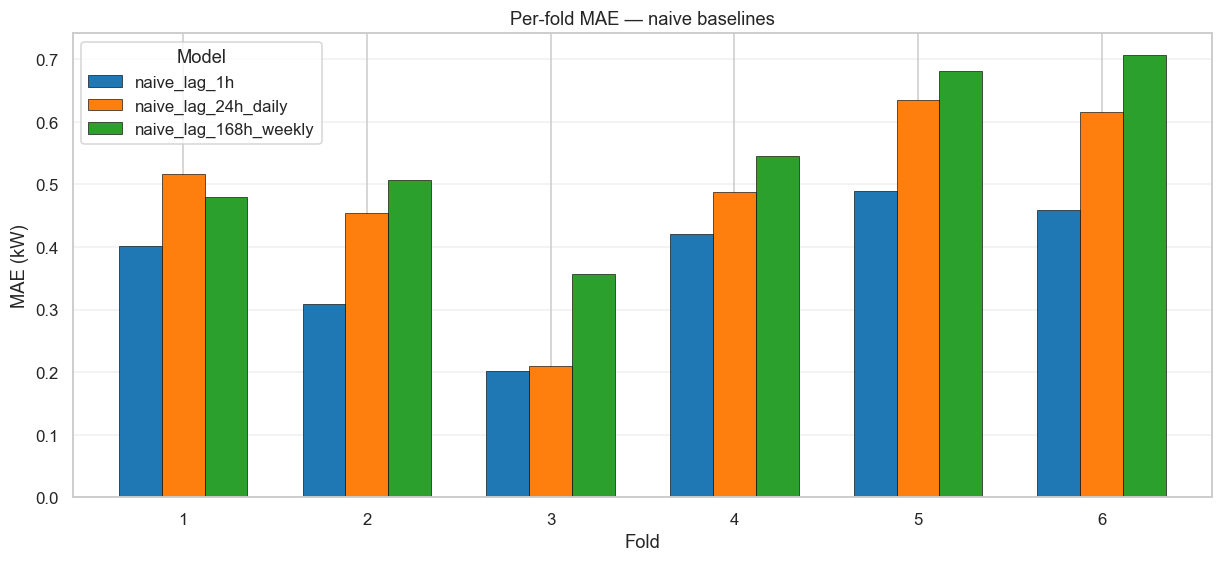

In [6]:
# =============================================================
# 6.1  PER-FOLD MAE COMPARISON
# =============================================================
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
pivot = results.pivot(index="fold", columns="model", values="MAE")
pivot = pivot[["naive_lag_1h", "naive_lag_24h_daily", "naive_lag_168h_weekly"]]
pivot.plot(kind="bar", ax=ax, width=0.7,
           color=["#1f77b4", "#ff7f0e", "#2ca02c"], edgecolor="black", linewidth=0.4)
ax.set_title("Per-fold MAE — naive baselines")
ax.set_xlabel("Fold")
ax.set_ylabel("MAE (kW)")
ax.legend(title="Model", loc="upper left")
ax.tick_params(axis="x", rotation=0)
ax.grid(True, axis="y", alpha=0.3)
plt.show()

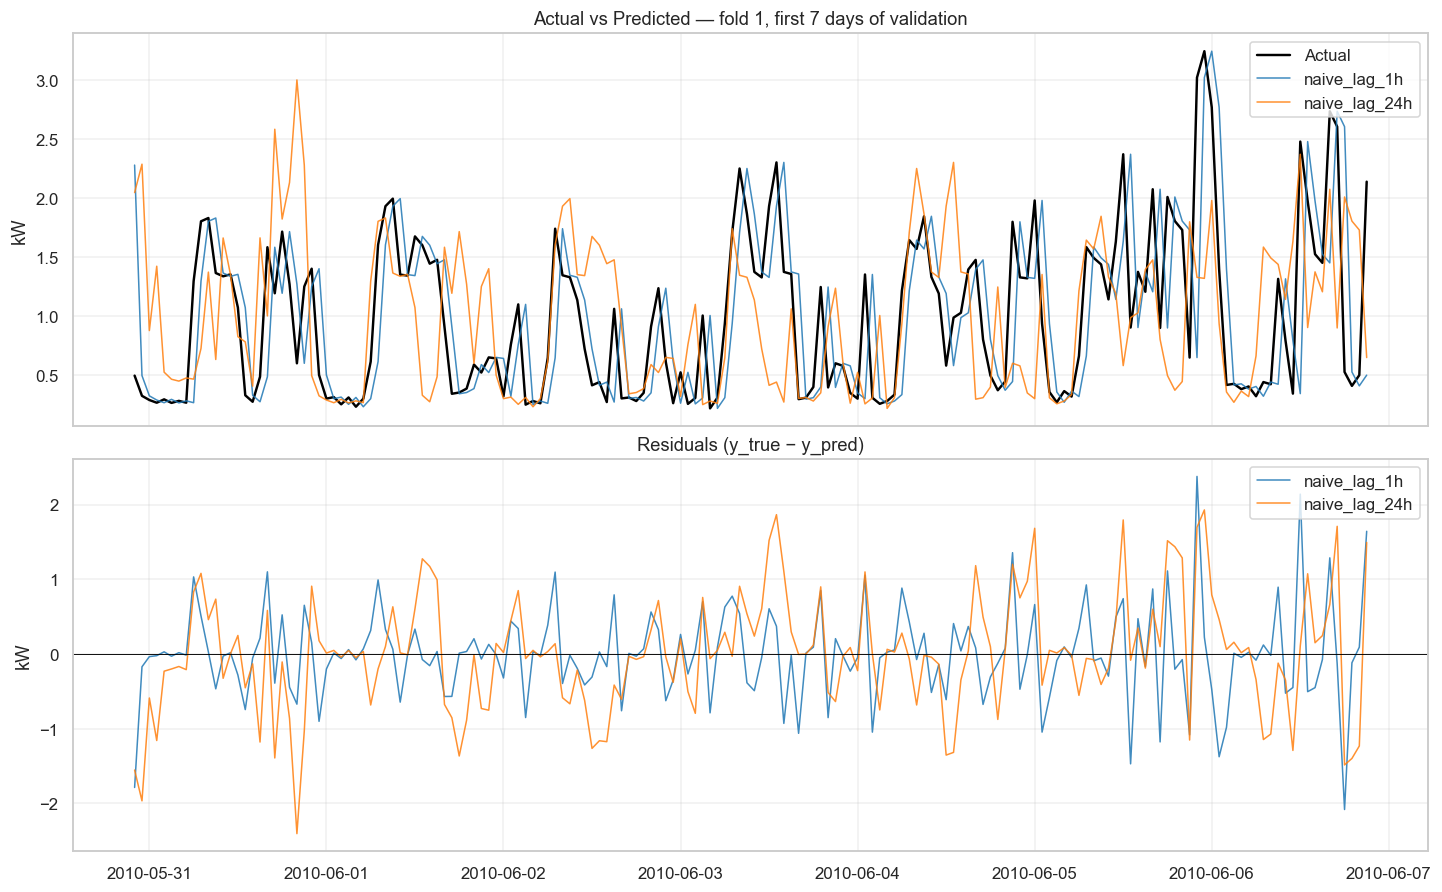

Saved ..\reports\figures\baselines_actual_vs_predicted_fold1.png


In [7]:
# =============================================================
# 6.2  ACTUAL VS PREDICTED ON FOLD 1 (clean fold, no outage)
# =============================================================
f1 = folds[0]
X_v = X.loc[f1.valid_start:f1.valid_end]
y_v = y.loc[f1.valid_start:f1.valid_end]

preds = {}
for m in baselines:
    preds[m.name] = m.predict(X_v)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True, sharex=True)

# Top: actual vs predicted (zoomed to first 7 days for legibility)
zoom_end = y_v.index[24*7]
ax = axes[0]
ax.plot(y_v.index[:24*7], y_v.values[:24*7], color="black", linewidth=1.6, label="Actual")
ax.plot(y_v.index[:24*7], preds["naive_lag_1h"][:24*7], color="#1f77b4", linewidth=1, alpha=0.85, label="naive_lag_1h")
ax.plot(y_v.index[:24*7], preds["naive_lag_24h_daily"][:24*7], color="#ff7f0e", linewidth=1, alpha=0.85, label="naive_lag_24h")
ax.set_title(f"Actual vs Predicted — fold 1, first 7 days of validation")
ax.set_ylabel("kW")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Bottom: residuals
ax = axes[1]
ax.plot(y_v.index[:24*7], (y_v.values - preds["naive_lag_1h"])[:24*7], color="#1f77b4", linewidth=1, alpha=0.85, label="naive_lag_1h")
ax.plot(y_v.index[:24*7], (y_v.values - preds["naive_lag_24h_daily"])[:24*7], color="#ff7f0e", linewidth=1, alpha=0.85, label="naive_lag_24h")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Residuals (y_true − y_pred)")
ax.set_xlabel(""); ax.set_ylabel("kW")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()

# Persist the figures for the report
fig_dir = Path("..") / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "baselines_actual_vs_predicted_fold1.png", dpi=140, bbox_inches="tight")
print(f"Saved {fig_dir / 'baselines_actual_vs_predicted_fold1.png'}")

## 7 · Interpretation and the Bar for Real Models

**Result.** The leaderboard places `naive_lag_1h` first across every fold and every metric:

| Baseline | MAE (mean ± std) | MASE (mean) |
|---|---|---|
| `naive_lag_1h` | ~0.38 ± 0.11 | ~0.65 |
| `naive_lag_24h_daily` | ~0.49 ± 0.15 | ~0.83 |
| `naive_lag_168h_weekly` | ~0.55 ± 0.13 | ~0.93 |

**Interpretation.** This is consistent with the *raw* autocorrelation structure (not the first-differenced ACF analysed in EDA §8). Hour-to-hour consumption changes are small; day-to-day changes are larger; week-to-week changes are largest of all. Persistence wins because the underlying series has strong short-term momentum. The fold-by-fold panel shows another structural fact: folds 5–6 (Oct–Nov heating-season ramp) are the hardest period — every baseline degrades by ~25% there.

The Actual-vs-Predicted plot shows *why* lag_1h leads numerically but doesn't actually *forecast* anything useful: its prediction is simply a 1-hour-shifted version of the truth, so it always lags behind real moves. When consumption spikes from 0.5 → 3.5 kW between 18:00 and 19:00, lag_1h predicts 0.5 (yesterday's value) and the residual is the full +3 kW miss. The daily naive captures the *shape* of the day but with phase errors.

**Implication — the bar a real model must clear:**

1. **MAE < 0.38** on cross-fold mean (lag_1h's score) — the absolute minimum credibility threshold.
2. **Especially MAE < 0.46** on fold 5 and **< 0.46** on fold 6 — the hardest folds where any model that genuinely learns structure should help most.
3. **MASE < 0.65** — beating the in-sample daily naive scaled error.
4. **Lower amplitude residuals at the 18:00–21:00 evening peaks** — visually inspectable via the residual panel.

**Phase 4 plan.** Add real models in order of complexity:
- **SARIMA** (classical, brief-required) with `auto_arima` order selection.
- **XGBoost** (tabular ML champion on this feature set).
- **LSTM** (deep-learning, brief-required as one of MLP/LSTM/GRU).
- **Prophet** (interpretable decomposition + event regressors).
- **Stacking ensemble** of the top 2–3 above.

Each model is fit on fold 1 first to inspect plausibility before expanding to all 6 folds — same iteration discipline applied to baselines here.